# Évaluation comparative des modèles d'embeddings dans un système RAG

Ce notebook évalue l'impact du choix du modèle d'embedding sur les performances d'un système RAG appliqué à un assistant virtuel académique du Master SIM.

L'objectif est de comparer automatiquement plusieurs embeddings Ollama en reconstruisant une base FAISS pour chaque modèle, puis en mesurant la qualité du retrieval et des réponses générées avec un LLM fixe.

## 1. Introduction

Dans une architecture RAG, le modèle d'embedding joue un rôle central : il transforme les documents et les questions en vecteurs numériques. La qualité de ces vecteurs influence directement la capacité du système à retrouver les bons passages avant la génération de réponse.

Cette expérimentation compare trois modèles d'embeddings :
- `qwen3-embedding`
- `nomic-embed-text`
- `mxbai-embed-large`

Le modèle de génération est volontairement fixé à `qwen2.5:3b` afin d'isoler l'effet des embeddings.

## 2. Chargement des bibliothèques et configuration des chemins

In [1]:
from __future__ import annotations

import re
import sys
import time
import shutil
import subprocess
import unicodedata
from difflib import SequenceMatcher
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from langchain_community.document_loaders import PyPDFLoader, TextLoader, Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document

# Détection robuste de la racine du projet.
# Le notebook peut être lancé depuis la racine ou depuis le dossier notebooks/.
CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise RuntimeError("Impossible de trouver le dossier src/. Lancez le notebook depuis le projet.")

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
EMBEDDINGS_RESULTS_DIR = RESULTS_DIR / "embeddings"
EMBEDDING_INDEXES_DIR = EMBEDDINGS_RESULTS_DIR / "indexes"

for directory in [RESULTS_DIR, PLOTS_DIR, EMBEDDINGS_RESULTS_DIR, EMBEDDING_INDEXES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Réutilisation du code existant pour la génération de réponse.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from llm_chain import ChainConfig, generate_answer, FALLBACK_MESSAGE

print(f"Projet : {PROJECT_ROOT}")
print(f"Documents : {DATA_DIR}")
print(f"Résultats embeddings : {EMBEDDINGS_RESULTS_DIR}")

/home/ibrahim/Bureau/Projets_de_Stage/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projet : /home/ibrahim/Bureau/Projets_de_Stage
Documents : /home/ibrahim/Bureau/Projets_de_Stage/data
Résultats embeddings : /home/ibrahim/Bureau/Projets_de_Stage/results/embeddings


## 3. Cellule de configuration expérimentale

Modifiez uniquement cette cellule pour changer les embeddings testés, les paramètres de chunking, le nombre de questions ou les paramètres de retrieval.

In [2]:
# Fichier Excel d'évaluation.
INPUT_EXCEL_PATH = Path("/home/ibrahim/Téléchargements/Evaluation_test_RAG_30_Questions.xlsx")

# Embeddings à comparer.
EMBEDDING_MODELS = [
    "qwen3-embedding",
    "nomic-embed-text",
    "mxbai-embed-large",
]

# LLM fixe pour isoler l'effet des embeddings.
LLM_MODEL = "qwen2.5:3b"

# Paramètres du découpage documentaire.
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 200

# Paramètres de retrieval.
TOP_K = 6
MAX_DISTANCE = 1.5

# Paramètres de génération.
REQUEST_TIMEOUT = 300
NUM_PREDICT = 512

# Nombre maximal de questions à tester.
# Mettre None pour utiliser toutes les questions du fichier Excel.
MAX_QUESTIONS = None

# Seuil pour transformer le score automatique en succès.
# Le score combine similarité lexicale, Jaccard et similarité de séquence.
SUCCESS_THRESHOLD = 0.42

TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
OUTPUT_EXCEL_PATH = EMBEDDINGS_RESULTS_DIR / f"evaluation_embeddings_{TIMESTAMP}.xlsx"
OUTPUT_CSV_PATH = EMBEDDINGS_RESULTS_DIR / f"evaluation_embeddings_{TIMESTAMP}.csv"

print("Embeddings testés :", EMBEDDING_MODELS)
print("LLM fixe :", LLM_MODEL)
print("Chunk size / overlap :", CHUNK_SIZE, CHUNK_OVERLAP)
print("Top K / Max distance :", TOP_K, MAX_DISTANCE)

Embeddings testés : ['qwen3-embedding', 'nomic-embed-text', 'mxbai-embed-large']
LLM fixe : qwen2.5:3b
Chunk size / overlap : 1000 200
Top K / Max distance : 6 1.5


## 4. Vérification des modèles Ollama

Cette étape vérifie que les modèles nécessaires sont disponibles localement. Si un modèle est absent, il faut l'installer avec `ollama pull <nom_du_modele>`.

In [4]:
def get_installed_ollama_models() -> List[str]:
    """Récupère les modèles Ollama installés localement."""
    try:
        completed = subprocess.run(
            ["ollama", "list"],
            capture_output=True,
            text=True,
            check=False,
        )
    except FileNotFoundError:
        return []

    models = []
    for line in completed.stdout.splitlines()[1:]:
        parts = line.split()
        if parts:
            models.append(parts[0])
    return models


def model_available(model_name: str, installed_models: List[str]) -> bool:
    """Accepte à la fois model et model:latest pour les modèles Ollama."""
    return model_name in installed_models or f"{model_name}:latest" in installed_models


installed_models = get_installed_ollama_models()
required_models = EMBEDDING_MODELS + [LLM_MODEL]
missing_models = [model for model in required_models if not model_available(model, installed_models)]

print("Modèles installés :")
for model in installed_models:
    print("-", model)

if missing_models:
    print("\nModèles absents :")
    for model in missing_models:
        print(f"- {model}  -> commande : ollama pull {model}")
else:
    print("\nTous les modèles nécessaires sont disponibles.")

Modèles installés :
- mxbai-embed-large:latest
- nomic-embed-text:latest
- mistral:7b
- llama3.2:3b
- qwen2.5:3b
- kimi-k2.6:cloud
- qwen3-embedding:latest
- qwen3.5:9b

Tous les modèles nécessaires sont disponibles.


## 5. Méthodologie

Pour chaque modèle d'embedding, le notebook exécute exactement le même protocole :

1. charger les documents académiques depuis `data/` ;
2. découper les documents avec `chunk_size=1000` et `chunk_overlap=200` ;
3. générer les embeddings avec le modèle testé ;
4. construire un index FAISS ;
5. sauvegarder l'index dans `results/embeddings/indexes/` ;
6. poser toutes les questions du fichier Excel ;
7. générer les réponses avec le même LLM (`qwen2.5:3b`) ;
8. mesurer les performances et exporter les résultats.

## 6. Chargement du jeu de questions

In [5]:
REQUIRED_COLUMNS = ["ID", "Type_Question", "Question", "Réponse_Attendue"]

if not INPUT_EXCEL_PATH.exists():
    raise FileNotFoundError(f"Fichier Excel introuvable : {INPUT_EXCEL_PATH}")

questions_df = pd.read_excel(INPUT_EXCEL_PATH)
questions_df = questions_df.dropna(how="all").copy()

missing_columns = [column for column in REQUIRED_COLUMNS if column not in questions_df.columns]
if missing_columns:
    raise ValueError(f"Colonnes manquantes : {missing_columns}")

questions_df = questions_df.dropna(subset=["Question"]).copy()
questions_df["Question"] = questions_df["Question"].astype(str).str.strip()
questions_df = questions_df[questions_df["Question"] != ""]

if MAX_QUESTIONS is not None:
    questions_df = questions_df.head(MAX_QUESTIONS).copy()

print(f"Nombre de questions chargées : {len(questions_df)}")
questions_df.head()

Nombre de questions chargées : 30


,ID,Type_Question,Categorie,Question,Réponse_Attendue,Réponse_Système,Pertinence (1-5),Exactitude (1-5),Fidélité_Source (1-5),Temps_Réponse,modele
0,1.0,Simple,Programme,Quelle est la durée du programme ?,De janvier 2024 à décembre 2025,Le programme dure de janvier 2024 à décembre 2...,5.0,5.0,4.0,"5,79s",qwen2.5:3b
1,2.0,Simple,Programme,Quel est le nom du programme ?,Master Informatique option SIM,"Le nom du programme est Informatique, option S...",5.0,5.0,5.0,"6,16s",qwen2.5:3b
2,3.0,Simple,Programme,Où se déroule la formation ?,À l’IFI – Université Nationale du Vietnam,a formation se déroule à l'Institut Francophon...,5.0,5.0,5.0,9.23 s,qwen2.5:3b
3,4.0,Simple,Bourse,Quel est le montant de la bourse mensuelle ?,1 500 000 VND par mois,Le montant de la bourse mensuelle pour les étu...,5.0,5.0,5.0,9.96 s,lama3.2:3b
4,5.0,Simple,Stage,Quelle est la durée minimale du stage ?,5 mois,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Fonctions d'ingestion et de reconstruction FAISS

In [6]:
def safe_model_name(model_name: str) -> str:
    """Transforme un nom de modèle en nom de dossier compatible avec le système de fichiers."""
    return re.sub(r"[^a-zA-Z0-9_.-]+", "_", model_name)


def load_one_document(file_path: Path) -> List[Document]:
    """Charge un document PDF, TXT ou DOCX avec les loaders LangChain."""
    suffix = file_path.suffix.lower()

    if suffix == ".pdf":
        loader = PyPDFLoader(str(file_path))
    elif suffix == ".txt":
        loader = TextLoader(str(file_path), encoding="utf-8")
    elif suffix == ".docx":
        loader = Docx2txtLoader(str(file_path))
    else:
        return []

    return loader.load()


def load_academic_documents(data_dir: Path) -> List[Document]:
    """Charge tous les documents académiques depuis le dossier data/."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Dossier data introuvable : {data_dir}")

    documents: List[Document] = []
    supported_extensions = {".pdf", ".txt", ".docx"}

    for file_path in sorted(data_dir.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in supported_extensions:
            try:
                loaded = load_one_document(file_path)
                documents.extend(loaded)
                print(f"Chargé : {file_path.name} ({len(loaded)} page(s)/document(s))")
            except Exception as exc:
                print(f"Erreur de chargement pour {file_path.name} : {exc}")

    if not documents:
        raise ValueError("Aucun document académique valide trouvé dans data/.")

    return documents


def split_documents(documents: List[Document], chunk_size: int, chunk_overlap: int) -> List[Document]:
    """Découpe les documents en chunks reproductibles."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
    )
    return splitter.split_documents(documents)


def build_faiss_index_for_embedding(embedding_model: str, chunks: List[Document]) -> Tuple[FAISS, Path, float]:
    """Construit et sauvegarde un index FAISS pour un modèle d'embedding donné."""
    index_dir = EMBEDDING_INDEXES_DIR / safe_model_name(embedding_model)

    # On supprime l'ancien index du même embedding pour garantir une expérience propre.
    if index_dir.exists():
        shutil.rmtree(index_dir)

    start_time = time.perf_counter()
    embeddings = OllamaEmbeddings(model=embedding_model)
    vectorstore = FAISS.from_documents(chunks, embeddings)
    build_time = round(time.perf_counter() - start_time, 3)

    index_dir.mkdir(parents=True, exist_ok=True)
    vectorstore.save_local(str(index_dir))

    return vectorstore, index_dir, build_time


raw_documents = load_academic_documents(DATA_DIR)
chunks = split_documents(raw_documents, CHUNK_SIZE, CHUNK_OVERLAP)

print(f"Nombre de documents/pages chargés : {len(raw_documents)}")
print(f"Nombre total de chunks : {len(chunks)}")

Chargé : Contrat_apprentissage_SIM.pdf (8 page(s)/document(s))
Chargé : Contrat_apprentissage_SIM_P27.pdf (6 page(s)/document(s))
Nombre de documents/pages chargés : 14
Nombre total de chunks : 72


## 8. Fonctions de retrieval et d'évaluation souple

In [7]:
def distance_to_similarity(distance: float) -> float:
    """Convertit une distance FAISS en score de similarité interprétable."""
    return round(float(1 / (1 + distance)), 4)


def retrieve_with_vectorstore(vectorstore: FAISS, query: str, top_k: int, max_distance: float) -> Tuple[List[Document], List[float]]:
    """Récupère les chunks pertinents pour une question à partir de l'index FAISS courant."""
    results = vectorstore.similarity_search_with_score(query, k=top_k)

    documents: List[Document] = []
    scores: List[float] = []

    for document, distance in results:
        if float(distance) <= max_distance:
            documents.append(document)
            scores.append(distance_to_similarity(float(distance)))

    return documents, scores


def extract_pages(documents: List[Document]) -> List[int]:
    """Extrait les pages uniques utilisées comme sources."""
    pages = []
    for document in documents:
        page = document.metadata.get("page")
        if isinstance(page, int):
            pages.append(page + 1)
    return sorted(set(pages))


def normalize_text(text: str) -> str:
    """Normalise un texte pour comparer des réponses reformulées."""
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def token_f1(expected: str, generated: str) -> float:
    """Score F1 lexical entre réponse attendue et réponse générée."""
    expected_tokens = normalize_text(expected).split()
    generated_tokens = normalize_text(generated).split()

    if not expected_tokens or not generated_tokens:
        return 0.0

    expected_counts: Dict[str, int] = {}
    for token in expected_tokens:
        expected_counts[token] = expected_counts.get(token, 0) + 1

    overlap = 0
    for token in generated_tokens:
        if expected_counts.get(token, 0) > 0:
            overlap += 1
            expected_counts[token] -= 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(generated_tokens)
    recall = overlap / len(expected_tokens)
    return (2 * precision * recall) / (precision + recall)


def jaccard_similarity(expected: str, generated: str) -> float:
    """Similarité de Jaccard entre les ensembles de tokens."""
    expected_tokens = set(normalize_text(expected).split())
    generated_tokens = set(normalize_text(generated).split())

    if not expected_tokens or not generated_tokens:
        return 0.0

    return len(expected_tokens & generated_tokens) / len(expected_tokens | generated_tokens)


def sequence_similarity(expected: str, generated: str) -> float:
    """Similarité globale de séquence, utile pour les reformulations proches."""
    return SequenceMatcher(None, normalize_text(expected), normalize_text(generated)).ratio()


def flexible_success_score(expected: str, generated: str) -> float:
    """Combine plusieurs métriques simples pour gérer les reformulations du LLM."""
    if not str(generated).strip() or generated.strip() == FALLBACK_MESSAGE:
        return 0.0

    f1 = token_f1(expected, generated)
    jaccard = jaccard_similarity(expected, generated)
    sequence = sequence_similarity(expected, generated)

    # Pondération pragmatique : le F1 capture les éléments clés, la séquence aide les réponses courtes.
    score = (0.55 * f1) + (0.25 * jaccard) + (0.20 * sequence)
    return round(float(score), 4)


def detect_potential_hallucination(answer: str, auto_score: float, documents: List[Document]) -> int:
    """Détection approximative : réponse présente, peu alignée à l'attendu ou sans contexte fiable."""
    if not str(answer).strip() or answer.strip() == FALLBACK_MESSAGE:
        return 0
    if not documents:
        return 1
    return int(auto_score < SUCCESS_THRESHOLD)

## 9. Pipeline d'évaluation RAG par embedding

In [8]:
def evaluate_question_with_embedding(row: pd.Series, embedding_model: str, vectorstore: FAISS, build_time: float, index_dir: Path) -> Dict[str, object]:
    """Évalue une question pour un embedding donné avec le LLM fixe."""
    question = str(row["Question"]).strip()
    expected_answer = str(row.get("Réponse_Attendue", "")).strip()

    start_time = time.perf_counter()
    status = "ok"
    error_message = ""
    documents: List[Document] = []
    scores: List[float] = []
    answer = ""

    try:
        documents, scores = retrieve_with_vectorstore(
            vectorstore=vectorstore,
            query=question,
            top_k=TOP_K,
            max_distance=MAX_DISTANCE,
        )

        answer = generate_answer(
            question=question,
            documents=documents,
            config=ChainConfig(
                llm_model=LLM_MODEL,
                request_timeout=REQUEST_TIMEOUT,
                num_predict=NUM_PREDICT,
            ),
        )

    except Exception as exc:
        status = "erreur"
        error_message = str(exc)

    elapsed_time = round(time.perf_counter() - start_time, 3)
    mean_similarity = round(float(np.mean(scores)), 4) if scores else 0.0
    max_similarity = round(float(np.max(scores)), 4) if scores else 0.0
    auto_score = flexible_success_score(expected_answer, answer)
    is_fallback = int(answer.strip() == FALLBACK_MESSAGE)
    answer_missing = int((not answer.strip()) or bool(is_fallback))
    retrieval_empty = int(len(documents) == 0)
    success = int(status == "ok" and answer_missing == 0 and auto_score >= SUCCESS_THRESHOLD)

    return {
        "ID": row.get("ID", ""),
        "Type_Question": row.get("Type_Question", ""),
        "Categorie": row.get("Categorie", ""),
        "Question": question,
        "Réponse_Attendue": expected_answer,
        "Embedding": embedding_model,
        "LLM": LLM_MODEL,
        "Réponse_Système": answer,
        "Temps_Réponse_s": elapsed_time,
        "Temps_Ingestion_Embedding_s": build_time,
        "Index_FAISS": str(index_dir),
        "Nombre_Chunks_Récupérés": len(documents),
        "Pages_Sources": ", ".join(map(str, extract_pages(documents))),
        "Scores_Similarité": ", ".join(f"{score:.4f}" for score in scores),
        "Score_Similarité_Moyen": mean_similarity,
        "Score_Similarité_Max": max_similarity,
        "Score_Succès_Souple": auto_score,
        "Succès_Auto": success,
        "Réponse_Absente": answer_missing,
        "Retrieval_Vide": retrieval_empty,
        "Fallback": is_fallback,
        "Hallucination_Potentielle": detect_potential_hallucination(answer, auto_score, documents),
        "Statut": status,
        "Erreur": error_message,
    }


all_results: List[Dict[str, object]] = []
ingestion_metadata: List[Dict[str, object]] = []

total_runs = len(EMBEDDING_MODELS) * len(questions_df)
progress = tqdm(total=total_runs, desc="Évaluation embeddings")

for embedding_model in EMBEDDING_MODELS:
    print(f"\nConstruction FAISS pour : {embedding_model}")
    vectorstore, index_dir, build_time = build_faiss_index_for_embedding(embedding_model, chunks)

    ingestion_metadata.append({
        "Embedding": embedding_model,
        "Nombre_Documents": len(raw_documents),
        "Nombre_Chunks_Total": len(chunks),
        "Chunk_Size": CHUNK_SIZE,
        "Chunk_Overlap": CHUNK_OVERLAP,
        "Temps_Ingestion_s": build_time,
        "Index_FAISS": str(index_dir),
    })

    for _, row in questions_df.iterrows():
        result = evaluate_question_with_embedding(row, embedding_model, vectorstore, build_time, index_dir)
        all_results.append(result)
        progress.update(1)

progress.close()

results_df = pd.DataFrame(all_results)
ingestion_df = pd.DataFrame(ingestion_metadata)

results_df.head()

Évaluation embeddings:   0%|          | 0/90 [00:00<?, ?it/s]


Construction FAISS pour : qwen3-embedding


Évaluation embeddings:  33%|███▎      | 30/90 [08:46<12:10, 12.17s/it]  


Construction FAISS pour : nomic-embed-text


Évaluation embeddings:  67%|██████▋   | 60/90 [11:23<02:39,  5.30s/it]


Construction FAISS pour : mxbai-embed-large


Évaluation embeddings: 100%|██████████| 90/90 [14:23<00:00,  9.60s/it]


,ID,Type_Question,Categorie,Question,Réponse_Attendue,Embedding,LLM,Réponse_Système,Temps_Réponse_s,Temps_Ingestion_Embedding_s,...,Score_Similarité_Moyen,Score_Similarité_Max,Score_Succès_Souple,Succès_Auto,Réponse_Absente,Retrieval_Vide,Fallback,Hallucination_Potentielle,Statut,Erreur
0,1.0,Simple,Programme,Quelle est la durée du programme ?,De janvier 2024 à décembre 2025,qwen3-embedding,qwen2.5:3b,Le programme dure de janvier 2024 à décembre 2...,8.489,198.158,...,0.4900,0.4998,0.7617,1,0,0,0,0,ok,
1,2.0,Simple,Programme,Quel est le nom du programme ?,Master Informatique option SIM,qwen3-embedding,qwen2.5:3b,Le nom du programme est Master en Informatique...,11.616,198.158,...,0.4622,0.4872,0.3485,0,0,0,0,1,ok,
2,3.0,Simple,Programme,Où se déroule la formation ?,À l’IFI – Université Nationale du Vietnam,qwen3-embedding,qwen2.5:3b,La formation se déroule dans les résidences un...,9.878,198.158,...,0.5105,0.5391,0.4822,1,0,0,0,0,ok,
3,4.0,Simple,Bourse,Quel est le montant de la bourse mensuelle ?,1 500 000 VND par mois,qwen3-embedding,qwen2.5:3b,Le montant de la bourse mensuelle pour les étu...,11.029,198.158,...,0.5583,0.5864,0.3753,0,0,0,0,1,ok,
4,5.0,Simple,Stage,Quelle est la durée minimale du stage ?,5 mois,qwen3-embedding,qwen2.5:3b,La durée minimale du stage est 5 mois.,10.409,198.158,...,0.5493,0.6000,0.3383,0,0,0,0,1,ok,


## 10. Résultats : tableaux de synthèse

In [9]:
performance_globale = (
    results_df.groupby("Embedding", dropna=False)
    .agg(
        Nombre_Tests=("Question", "count"),
        Taux_Réussite=("Succès_Auto", "mean"),
        Score_Succès_Moyen=("Score_Succès_Souple", "mean"),
        Score_Similarité_Moyen=("Score_Similarité_Moyen", "mean"),
        Score_Similarité_Max_Moyen=("Score_Similarité_Max", "mean"),
        Temps_Moyen_s=("Temps_Réponse_s", "mean"),
        Chunks_Moyens=("Nombre_Chunks_Récupérés", "mean"),
        Réponses_Absentes=("Réponse_Absente", "sum"),
        Retrievals_Vides=("Retrieval_Vide", "sum"),
        Hallucinations_Potentielles=("Hallucination_Potentielle", "sum"),
    )
    .reset_index()
)

performance_par_difficulte = (
    results_df.groupby(["Embedding", "Type_Question"], dropna=False)
    .agg(
        Nombre_Tests=("Question", "count"),
        Taux_Réussite=("Succès_Auto", "mean"),
        Score_Succès_Moyen=("Score_Succès_Souple", "mean"),
        Score_Similarité_Moyen=("Score_Similarité_Moyen", "mean"),
        Temps_Moyen_s=("Temps_Réponse_s", "mean"),
        Chunks_Moyens=("Nombre_Chunks_Récupérés", "mean"),
    )
    .reset_index()
)

performance_par_embedding = performance_globale.merge(
    ingestion_df[["Embedding", "Temps_Ingestion_s", "Nombre_Chunks_Total"]],
    on="Embedding",
    how="left",
)

performance_globale

,Embedding,Nombre_Tests,Taux_Réussite,Score_Succès_Moyen,Score_Similarité_Moyen,Score_Similarité_Max_Moyen,Temps_Moyen_s,Chunks_Moyens,Réponses_Absentes,Retrievals_Vides,Hallucinations_Potentielles
0,mxbai-embed-large,30,0.033333,0.146367,0.62994,0.653350,5.259700,6.0,2,0,27
1,nomic-embed-text,30,0.033333,0.134233,0.64800,0.673577,4.982133,6.0,4,0,25
2,qwen3-embedding,30,0.066667,0.192970,0.56617,0.598227,10.943900,6.0,1,0,27


In [10]:
performance_par_difficulte

,Embedding,Type_Question,Nombre_Tests,Taux_Réussite,Score_Succès_Moyen,Score_Similarité_Moyen,Temps_Moyen_s,Chunks_Moyens
0,mxbai-embed-large,Complexe,10,0.0,0.08252,0.63793,5.7471,6.0
1,mxbai-embed-large,Moyenne,10,0.0,0.14314,0.63424,5.2482,6.0
2,mxbai-embed-large,Simple,10,0.1,0.21344,0.61765,4.7838,6.0
3,nomic-embed-text,Complexe,10,0.0,0.10085,0.66549,5.2728,6.0
4,nomic-embed-text,Moyenne,10,0.0,0.14109,0.66560,4.9811,6.0
5,nomic-embed-text,Simple,10,0.1,0.16076,0.61291,4.6925,6.0
6,qwen3-embedding,Complexe,10,0.0,0.13627,0.60044,11.6444,6.0
7,qwen3-embedding,Moyenne,10,0.0,0.20317,0.57298,10.5931,6.0
8,qwen3-embedding,Simple,10,0.2,0.23947,0.52509,10.5942,6.0


## 11. Sauvegarde Excel et CSV

In [11]:
results_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUTPUT_EXCEL_PATH, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="resultats_detail", index=False)
    performance_globale.to_excel(writer, sheet_name="performance_globale", index=False)
    performance_par_difficulte.to_excel(writer, sheet_name="par_difficulte", index=False)
    performance_par_embedding.to_excel(writer, sheet_name="par_embedding", index=False)
    ingestion_df.to_excel(writer, sheet_name="ingestion", index=False)

print(f"Résultats CSV : {OUTPUT_CSV_PATH}")
print(f"Résultats Excel : {OUTPUT_EXCEL_PATH}")

Résultats CSV : /home/ibrahim/Bureau/Projets_de_Stage/results/embeddings/evaluation_embeddings_20260527_001757.csv
Résultats Excel : /home/ibrahim/Bureau/Projets_de_Stage/results/embeddings/evaluation_embeddings_20260527_001757.xlsx


## 12. Visualisations avec matplotlib

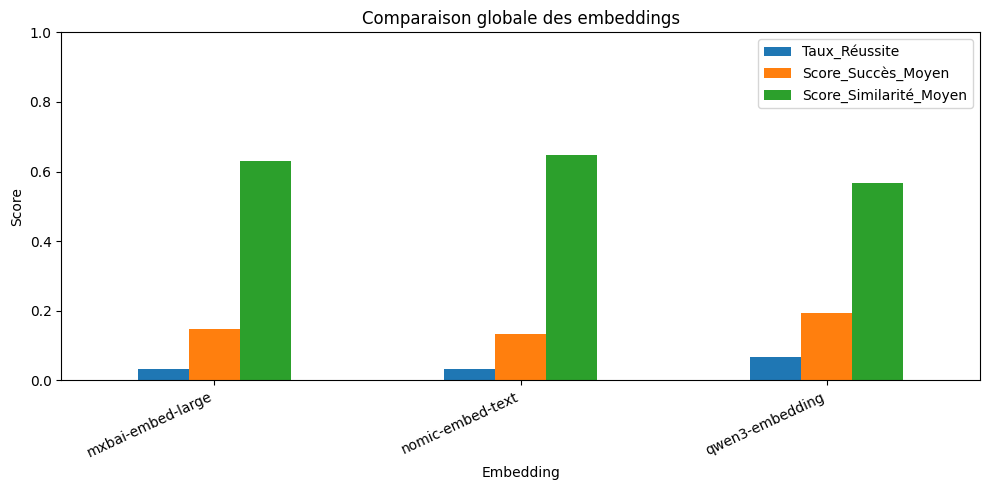

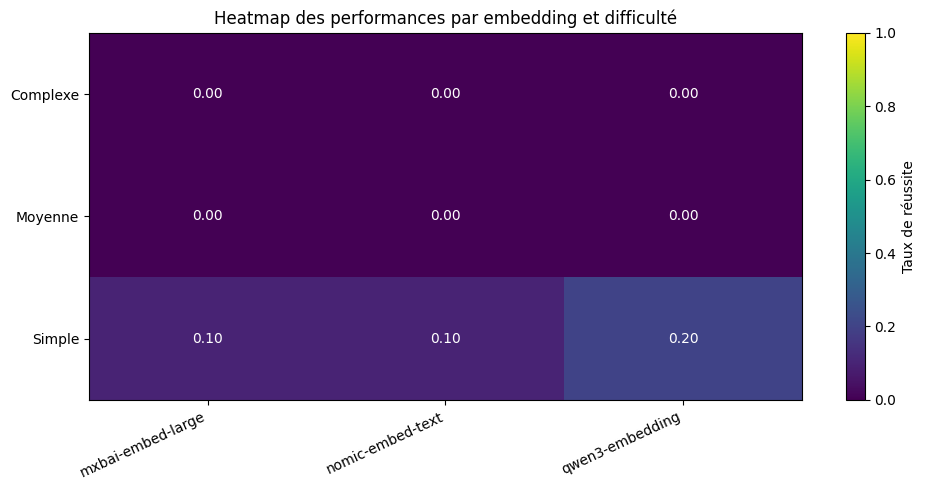

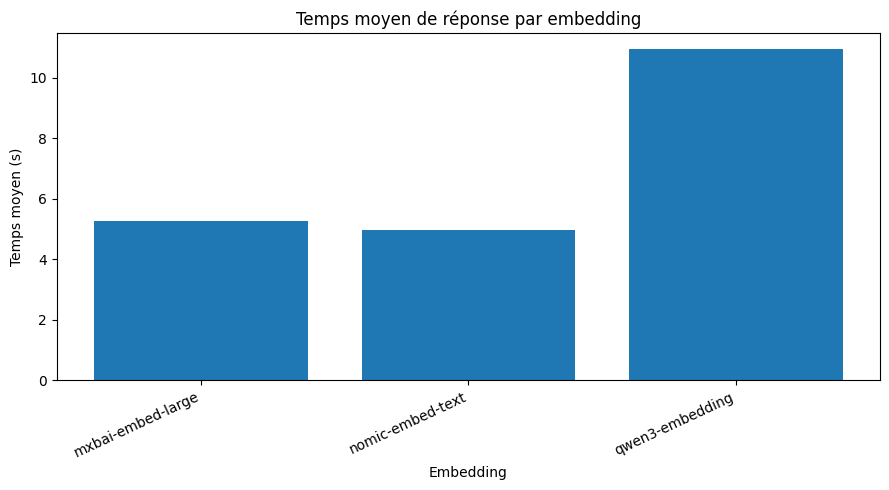

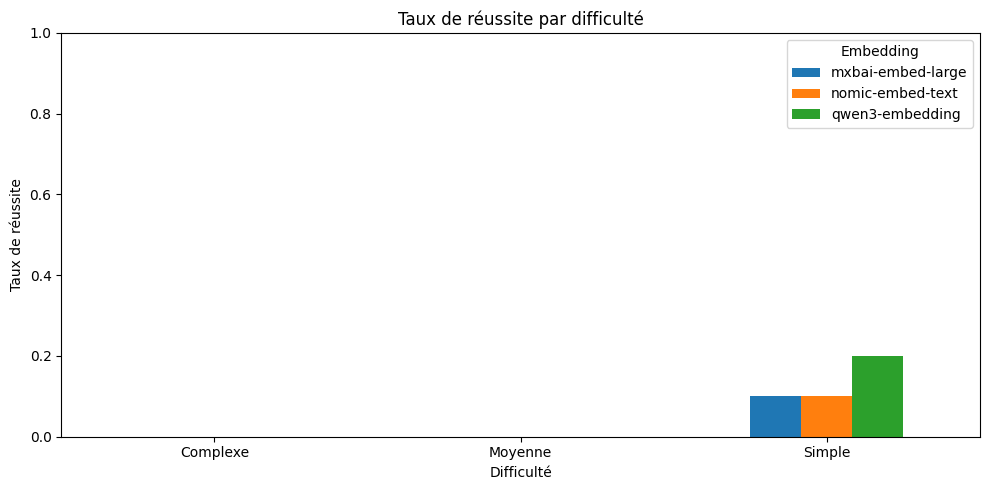

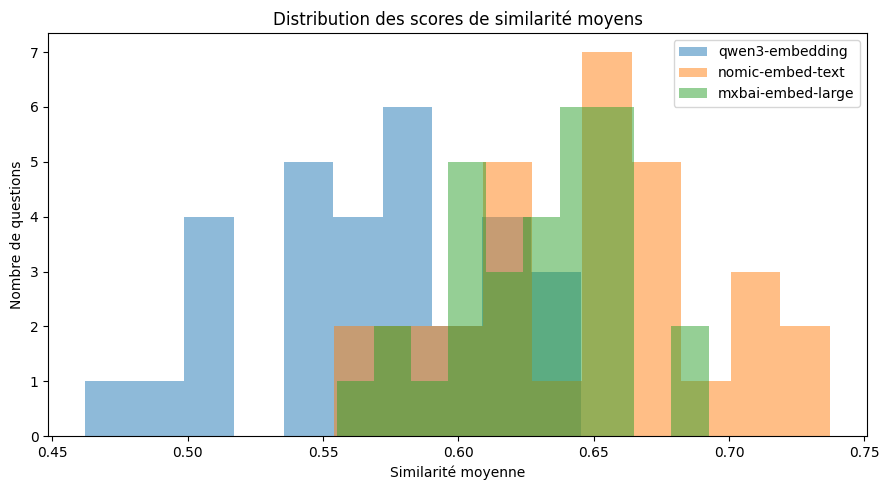

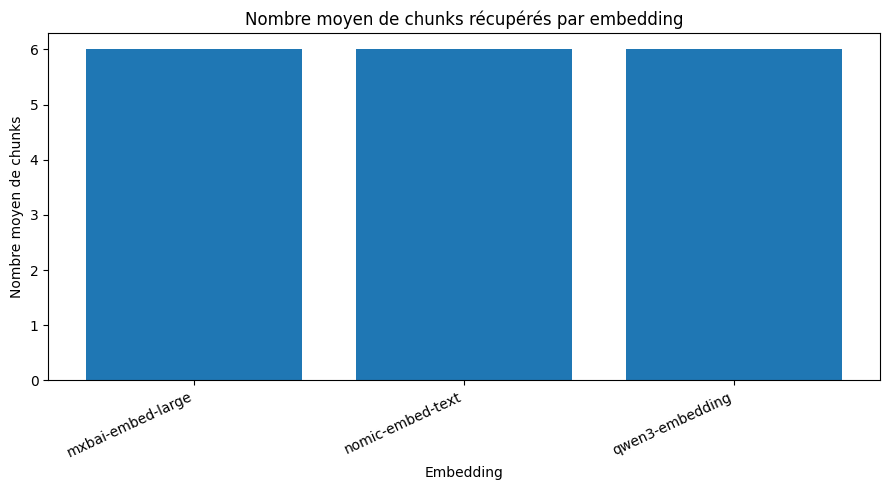

Graphiques sauvegardés dans : /home/ibrahim/Bureau/Projets_de_Stage/results/plots


In [12]:
def save_plot(filename: str) -> Path:
    """Sauvegarde la figure courante dans results/plots/."""
    path = PLOTS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    return path


# 1. Comparaison globale des embeddings.
comparison = performance_globale.set_index("Embedding")[[
    "Taux_Réussite",
    "Score_Succès_Moyen",
    "Score_Similarité_Moyen",
]]
comparison.plot(kind="bar", figsize=(10, 5))
plt.title("Comparaison globale des embeddings")
plt.xlabel("Embedding")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
save_plot("embeddings_comparaison_globale.png")
plt.show()

# 2. Heatmap des performances par difficulté.
heatmap_data = performance_par_difficulte.pivot(
    index="Type_Question",
    columns="Embedding",
    values="Taux_Réussite",
).fillna(0)

plt.figure(figsize=(10, 5))
plt.imshow(heatmap_data.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Taux de réussite")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=25, ha="right")
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Heatmap des performances par embedding et difficulté")
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(j, i, f"{heatmap_data.values[i, j]:.2f}", ha="center", va="center", color="white")
save_plot("embeddings_heatmap_performances.png")
plt.show()

# 3. Temps moyen de réponse.
plt.figure(figsize=(9, 5))
plt.bar(performance_globale["Embedding"], performance_globale["Temps_Moyen_s"])
plt.title("Temps moyen de réponse par embedding")
plt.xlabel("Embedding")
plt.ylabel("Temps moyen (s)")
plt.xticks(rotation=25, ha="right")
save_plot("embeddings_temps_moyen.png")
plt.show()

# 4. Succès par difficulté.
success_by_difficulty = performance_par_difficulte.pivot(
    index="Type_Question",
    columns="Embedding",
    values="Taux_Réussite",
)
success_by_difficulty.plot(kind="bar", figsize=(10, 5))
plt.title("Taux de réussite par difficulté")
plt.xlabel("Difficulté")
plt.ylabel("Taux de réussite")
plt.ylim(0, 1)
plt.xticks(rotation=0)
save_plot("embeddings_succes_par_difficulte.png")
plt.show()

# 5. Distribution des similarités.
plt.figure(figsize=(9, 5))
for embedding_model in EMBEDDING_MODELS:
    values = results_df.loc[results_df["Embedding"] == embedding_model, "Score_Similarité_Moyen"]
    plt.hist(values, bins=10, alpha=0.5, label=embedding_model)
plt.title("Distribution des scores de similarité moyens")
plt.xlabel("Similarité moyenne")
plt.ylabel("Nombre de questions")
plt.legend()
save_plot("embeddings_distribution_similarites.png")
plt.show()

# 6. Nombre moyen de chunks récupérés.
plt.figure(figsize=(9, 5))
plt.bar(performance_globale["Embedding"], performance_globale["Chunks_Moyens"])
plt.title("Nombre moyen de chunks récupérés par embedding")
plt.xlabel("Embedding")
plt.ylabel("Nombre moyen de chunks")
plt.xticks(rotation=25, ha="right")
save_plot("embeddings_chunks_moyens.png")
plt.show()

print(f"Graphiques sauvegardés dans : {PLOTS_DIR}")

## 13. Analyse des erreurs

In [13]:
retrieval_errors = results_df[
    (results_df["Retrieval_Vide"] == 1)
    | (results_df["Nombre_Chunks_Récupérés"] == 0)
    | (results_df["Score_Similarité_Moyen"] == 0)
].copy()

incorrect_or_weak_chunks = results_df[
    (results_df["Nombre_Chunks_Récupérés"] > 0)
    & (results_df["Score_Similarité_Moyen"] < results_df["Score_Similarité_Moyen"].median())
].copy()

potential_hallucinations = results_df[results_df["Hallucination_Potentielle"] == 1].copy()

complex_questions = results_df[results_df["Type_Question"].astype(str).str.lower() == "complexe"].copy()

error_analysis_path = EMBEDDINGS_RESULTS_DIR / f"analyse_erreurs_embeddings_{TIMESTAMP}.xlsx"
with pd.ExcelWriter(error_analysis_path, engine="openpyxl") as writer:
    retrieval_errors.to_excel(writer, sheet_name="erreurs_retrieval", index=False)
    incorrect_or_weak_chunks.to_excel(writer, sheet_name="chunks_faibles", index=False)
    potential_hallucinations.to_excel(writer, sheet_name="hallucinations", index=False)
    complex_questions.to_excel(writer, sheet_name="questions_complexes", index=False)

print(f"Erreurs retrieval : {len(retrieval_errors)}")
print(f"Chunks faibles ou possiblement incorrects : {len(incorrect_or_weak_chunks)}")
print(f"Hallucinations potentielles : {len(potential_hallucinations)}")
print(f"Questions complexes analysées : {len(complex_questions)}")
print(f"Fichier d'analyse des erreurs : {error_analysis_path}")

potential_hallucinations[["ID", "Embedding", "Type_Question", "Question", "Réponse_Attendue", "Réponse_Système", "Score_Succès_Souple", "Pages_Sources"]].head(20)

Erreurs retrieval : 0
Chunks faibles ou possiblement incorrects : 45
Hallucinations potentielles : 79
Questions complexes analysées : 30
Fichier d'analyse des erreurs : /home/ibrahim/Bureau/Projets_de_Stage/results/embeddings/analyse_erreurs_embeddings_20260527_001757.xlsx


,ID,Embedding,Type_Question,Question,Réponse_Attendue,Réponse_Système,Score_Succès_Souple,Pages_Sources
1,2.0,qwen3-embedding,Simple,Quel est le nom du programme ?,Master Informatique option SIM,Le nom du programme est Master en Informatique...,0.3485,"1, 2"
3,4.0,qwen3-embedding,Simple,Quel est le montant de la bourse mensuelle ?,1 500 000 VND par mois,Le montant de la bourse mensuelle pour les étu...,0.3753,"3, 4, 5"
4,5.0,qwen3-embedding,Simple,Quelle est la durée minimale du stage ?,5 mois,La durée minimale du stage est 5 mois.,0.3383,"2, 3"
5,6.0,qwen3-embedding,Simple,La soutenance est-elle obligatoire ?,Oui,La soutenance du mémoire n'est pas obligatoire...,0.0162,"2, 3"
6,7.0,qwen3-embedding,Simple,L’assurance santé est-elle obligatoire ?,Oui,"Oui, l'assurance santé est obligatoire pour le...",0.0370,"5, 6"
7,8.0,qwen3-embedding,Simple,Le plagiat est-il autorisé ?,Non,Ne fait pas du plagiat dans tous les travaux a...,0.0136,"1, 2, 3"
8,9.0,qwen3-embedding,Simple,Les examens sont-ils surveillés ?,Oui,Tous les examens sont surveillés par le person...,0.0158,2
9,10.0,qwen3-embedding,Simple,Les absences doivent-elles être justifiées ?,Oui,Absences nécessitent une justification valable...,0.0061,"2, 4"
10,11.0,qwen3-embedding,Moyenne,Que se passe-t-il si un étudiant dépasse 20 % ...,Il doit reprendre le module,Si un étudiant dépasse 20% de son absence dans...,0.3267,"2, 4, 5"
11,12.0,qwen3-embedding,Moyenne,Quand faut-il chercher un stage ?,Dès le début du Master 2,La Partie B doit chercher activement un stage ...,0.3900,"2, 3"


## 14. Commentaires académiques automatiques

In [14]:
comments: List[str] = []

if not performance_globale.empty:
    best_success = performance_globale.sort_values("Taux_Réussite", ascending=False).iloc[0]
    best_similarity = performance_globale.sort_values("Score_Similarité_Moyen", ascending=False).iloc[0]
    fastest = performance_globale.sort_values("Temps_Moyen_s", ascending=True).iloc[0]

    comments.append(
        f"{best_success['Embedding']} obtient le meilleur taux de réussite global "
        f"({best_success['Taux_Réussite']:.2%}), ce qui indique une meilleure adéquation retrieval-génération dans cette expérimentation."
    )
    comments.append(
        f"{best_similarity['Embedding']} présente le score moyen de similarité le plus élevé "
        f"({best_similarity['Score_Similarité_Moyen']:.3f}), ce qui suggère une récupération sémantique plus forte."
    )
    comments.append(
        f"{fastest['Embedding']} donne le temps moyen de réponse le plus faible "
        f"({fastest['Temps_Moyen_s']:.2f} s), ce qui peut être important pour une interface conversationnelle."
    )

if "Complexe" in performance_par_difficulte["Type_Question"].astype(str).unique():
    complex_perf = performance_par_difficulte[performance_par_difficulte["Type_Question"].astype(str) == "Complexe"]
    if not complex_perf.empty:
        best_complex = complex_perf.sort_values("Taux_Réussite", ascending=False).iloc[0]
        comments.append(
            f"{best_complex['Embedding']} améliore les performances sur les questions complexes "
            f"avec un taux de réussite de {best_complex['Taux_Réussite']:.2%}."
        )

for embedding_model in EMBEDDING_MODELS:
    subset = results_df[results_df["Embedding"] == embedding_model]
    if subset.empty:
        continue

    fallback_rate = subset["Fallback"].mean()
    hallucination_rate = subset["Hallucination_Potentielle"].mean()

    if fallback_rate > 0.20:
        comments.append(
            f"{embedding_model} montre des limites sur certaines paraphrases ou questions indirectes, "
            f"avec {fallback_rate:.2%} de réponses d'absence d'information."
        )
    if hallucination_rate > 0.20:
        comments.append(
            f"{embedding_model} nécessite une analyse qualitative complémentaire, car le taux d'hallucinations potentielles atteint {hallucination_rate:.2%}."
        )

if "nomic-embed-text" in EMBEDDING_MODELS:
    comments.append(
        "nomic-embed-text peut améliorer la récupération sémantique lorsque les questions sont formulées différemment du texte source ; cette hypothèse doit être confirmée par les scores détaillés."
    )
if "mxbai-embed-large" in EMBEDDING_MODELS:
    comments.append(
        "mxbai-embed-large est particulièrement pertinent à analyser sur les questions complexes, car sa taille peut favoriser des représentations sémantiques plus riches."
    )
if "qwen3-embedding" in EMBEDDING_MODELS:
    comments.append(
        "qwen3-embedding sert de référence locale cohérente avec l'écosystème Qwen, mais peut montrer des limites si les formulations des questions s'éloignent fortement du PDF."
    )

comments_path = EMBEDDINGS_RESULTS_DIR / f"commentaires_embeddings_{TIMESTAMP}.txt"
comments_path.write_text("\n".join(f"- {comment}" for comment in comments), encoding="utf-8")

for comment in comments:
    print("-", comment)

print(f"Commentaires sauvegardés : {comments_path}")

- qwen3-embedding obtient le meilleur taux de réussite global (6.67%), ce qui indique une meilleure adéquation retrieval-génération dans cette expérimentation.
- nomic-embed-text présente le score moyen de similarité le plus élevé (0.648), ce qui suggère une récupération sémantique plus forte.
- nomic-embed-text donne le temps moyen de réponse le plus faible (4.98 s), ce qui peut être important pour une interface conversationnelle.
- mxbai-embed-large améliore les performances sur les questions complexes avec un taux de réussite de 0.00%.
- qwen3-embedding nécessite une analyse qualitative complémentaire, car le taux d'hallucinations potentielles atteint 90.00%.
- nomic-embed-text nécessite une analyse qualitative complémentaire, car le taux d'hallucinations potentielles atteint 83.33%.
- mxbai-embed-large nécessite une analyse qualitative complémentaire, car le taux d'hallucinations potentielles atteint 90.00%.
- nomic-embed-text peut améliorer la récupération sémantique lorsque les q

## 15. Limites

Cette évaluation automatique fournit des indicateurs utiles, mais elle comporte plusieurs limites :

- le score de succès souple reste lexical et ne remplace pas une évaluation humaine ;
- deux réponses peuvent être équivalentes sur le fond mais obtenir un score automatique moyen ;
- une bonne similarité FAISS ne garantit pas toujours que le chunk contient exactement la réponse ;
- les résultats dépendent du chunking, du seuil `max_distance`, du `top_k` et du prompt de génération ;
- les hallucinations potentielles doivent être confirmées par lecture manuelle des sources.

## 16. Conclusion

Ce notebook produit une expérimentation reproductible pour comparer l'impact de plusieurs embeddings dans un système RAG académique.

Les fichiers générés dans `results/embeddings/` et les figures PNG dans `results/plots/` peuvent être directement utilisés pour alimenter les tableaux, graphiques et analyses d'un mémoire de Master en Intelligence Artificielle.